In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("/content/Customers.csv")
products = pd.read_csv("/content/Products.csv")
categories = pd.read_csv("/content/Categories.csv")
orders = pd.read_csv("/content/orders.csv")
order_items = pd.read_csv("/content/Order_items.csv")
payments = pd.read_csv("/content/Payments.csv")
shipping = pd.read_csv("/content/Shipping.csv")

In [3]:
total_customers= customers['customer_id'].nunique()
print("Total Customers:",total_customers)

Total Customers: 5000


In [9]:
total_orders= orders['order_id'].nunique()
print("Total Orders:",total_orders)


Total Orders: 8000


In [16]:
total_categories= categories['category_id'].nunique()
print("Total Categories:",total_categories)

Total Categories: 10


In [17]:
total_revenue= orders['total_amount'].sum()
print("Total Revenue:",round(total_revenue,2))

Total Revenue: 1208788155.13


In [13]:
average_order_value= orders['total_amount'].mean()
round(average_order_value,2)

np.float64(151098.52)

In [18]:
total_products= products['product_id'].nunique()
print("Total Products:",total_products)

Total Products: 1000


In [20]:
top_products = (
    order_items
    .merge(products,on='product_id')
    .groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_name
Jeans         1755
Sofa          1644
Sunglasses    1612
Shampoo       1599
Rice          1563
Smart TV      1491
Doll          1491
Toy Car       1454
Pan           1438
Chair         1403
Name: quantity, dtype: int64


In [21]:
category_sales = (
    order_items
    .merge(products,on='product_id')
    .merge(categories,on='category_id')
)

top_categories = (
    category_sales
    .groupby('category_name')
    .apply(lambda x:(x['quantity']*x['unit_price']).sum())
    .sort_values(ascending=False)
)

print(top_categories)

category_name
Sports         1.253854e+08
Toys           1.225443e+08
Books          1.220817e+08
Kitchen        1.214252e+08
Accessories    1.211778e+08
Beauty         1.208569e+08
Electronics    1.198460e+08
Groceries      1.197297e+08
Home           1.189944e+08
Fashion        1.167467e+08
dtype: float64


/tmp/ipykernel_2652/2538451879.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:(x['quantity']*x['unit_price']).sum())


In [22]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

monthly_sales = (
    orders
    .groupby(orders['order_date'].dt.to_period('M'))
    ['total_amount']
    .sum()
)

print(monthly_sales)

order_date
2024-01    42621947.63
2024-02    40161333.71
2024-03    39232942.31
2024-04    43152334.92
2024-05    41502226.48
2024-06    39846669.08
2024-07    47430813.57
2024-08    41932858.87
2024-09    41398857.84
2024-10    44527926.01
2024-11    41485955.46
2024-12    42034060.29
2025-01    44265922.28
2025-02    35897262.75
2025-03    38056630.37
2025-04    45035283.01
2025-05    42262421.10
2025-06    39065716.79
2025-07    38775588.64
2025-08    40882086.23
2025-09    47877051.87
2025-10    47115114.90
2025-11    38796632.68
2025-12    37628081.28
2026-01    42323371.26
2026-02    36096466.96
2026-03    47060861.02
2026-04    42432561.84
2026-05    39889175.98
Freq: M, Name: total_amount, dtype: float64


In [23]:
top_customers = (
    orders
    .groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_customers)

customer_id
2416    1746169.42
392     1434702.41
2249    1362243.29
1268    1322122.82
538     1268297.12
Name: total_amount, dtype: float64


In [24]:
state_revenue = (
    orders
    .merge(customers,on='customer_id')
    .groupby('state')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue)

state
Delhi          2.087911e+08
Tamil Nadu     2.059975e+08
Telangana      2.031777e+08
West Bengal    2.012858e+08
Maharashtra    2.004104e+08
Karnataka      1.891256e+08
Name: total_amount, dtype: float64


In [25]:
city_revenue = (
    orders
    .merge(customers,on='customer_id')
    .groupby('city')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

print(city_revenue)

city
Delhi        2.087911e+08
Chennai      2.059975e+08
Hyderabad    2.031777e+08
Kolkata      2.012858e+08
Pune         2.004104e+08
Bengaluru    1.891256e+08
Name: total_amount, dtype: float64


In [26]:
payment_analysis = (
    payments
    .groupby('payment_method')
    .size()
    .sort_values(ascending=False)
)

print(payment_analysis)

payment_method
COD            1667
UPI            1628
Credit Card    1604
Net Banking    1568
Debit Card     1533
dtype: int64


In [27]:
status_analysis = (
    orders
    .groupby('order_status')
    .size()
)

print(status_analysis)

order_status
Cancelled     2102
Delivered     1959
Processing    1969
Shipped       1970
dtype: int64


In [28]:
gender_revenue = (
    orders
    .merge(customers,on='customer_id')
    .groupby('gender')['total_amount']
    .sum()
)

print(gender_revenue)

gender
Female    6.161258e+08
Male      5.926624e+08
Name: total_amount, dtype: float64


In [29]:
brand_revenue = (
    order_items
    .merge(products,on='product_id')
)

brand_revenue = (
    brand_revenue
    .groupby('brand')
    .apply(lambda x:(x['quantity']*x['unit_price']).sum())
    .sort_values(ascending=False)
)

print(brand_revenue)

brand
Cosco            52217844.64
Prestige         49448208.41
Wildcraft        48914623.91
Aashirvaad       46275694.19
IKEA             45105265.14
Funskool         44057760.65
Loreal           43752810.66
HarperCollins    42848599.01
Maybelline       42427836.50
Lego             42137833.23
Pigeon           42124362.66
Penguin          39765394.80
Nivia            39721643.26
Oxford           39467738.70
Nilkamal         39192432.73
H&M              38111348.09
Fortune          37265436.46
Titan            36580305.35
Mattel           36348721.50
Tata             36188617.80
Fastrack         35682878.03
Dell             34742906.48
HomeCentre       34696750.09
Lakme            34676243.08
SG               33445897.22
Apple            31765532.33
Zara             30941119.03
Butterfly        29852581.98
Samsung          29023818.20
Puma             28112240.11
Sony             24313711.57
Levis            19581999.32
dtype: float64


/tmp/ipykernel_2652/2339298892.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:(x['quantity']*x['unit_price']).sum())


In [30]:
monthly_orders = (
    orders
    .groupby(orders['order_date'].dt.to_period('M'))
    ['order_id']
    .count()
)

print(monthly_orders)

order_date
2024-01    277
2024-02    273
2024-03    259
2024-04    285
2024-05    276
2024-06    270
2024-07    306
2024-08    270
2024-09    275
2024-10    289
2024-11    265
2024-12    284
2025-01    289
2025-02    229
2025-03    286
2025-04    288
2025-05    277
2025-06    255
2025-07    273
2025-08    278
2025-09    300
2025-10    291
2025-11    266
2025-12    266
2026-01    295
2026-02    237
2026-03    295
2026-04    271
2026-05    275
Freq: M, Name: order_id, dtype: int64


In [31]:
courier_analysis = (
    shipping
    .groupby('courier_name')
    .size()
    .sort_values(ascending=False)
)

print(courier_analysis)

courier_name
Ekart        2044
Delhivery    2000
DTDC         1985
Blue Dart    1971
dtype: int64


In [32]:
clv = (
    orders
    .groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

print(clv.head())

customer_id
2416    1746169.42
392     1434702.41
2249    1362243.29
1268    1322122.82
538     1268297.12
Name: total_amount, dtype: float64


In [33]:
top20 = (
    orders
    .groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print(top20)

customer_id
2416    1746169.42
392     1434702.41
2249    1362243.29
1268    1322122.82
538     1268297.12
4396    1226000.78
3342    1181861.40
277     1178883.56
4023    1176945.06
3790    1157548.43
1006    1151982.34
221     1146671.51
2116    1140777.76
1646    1139608.27
3279    1137891.41
2548    1133738.92
205     1123241.38
2100    1116674.21
2741    1114101.55
685     1109693.80
Name: total_amount, dtype: float64


In [34]:
repeat_customers = (
    orders
    .groupby('customer_id')
    .size()
)

repeat_customers = repeat_customers[repeat_customers > 1]

print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 2347


In [35]:
new_customers = (
    orders
    .groupby('customer_id')
    .size()
)

new_customers = new_customers[new_customers == 1]

print("New Customers:", len(new_customers))

New Customers: 1629


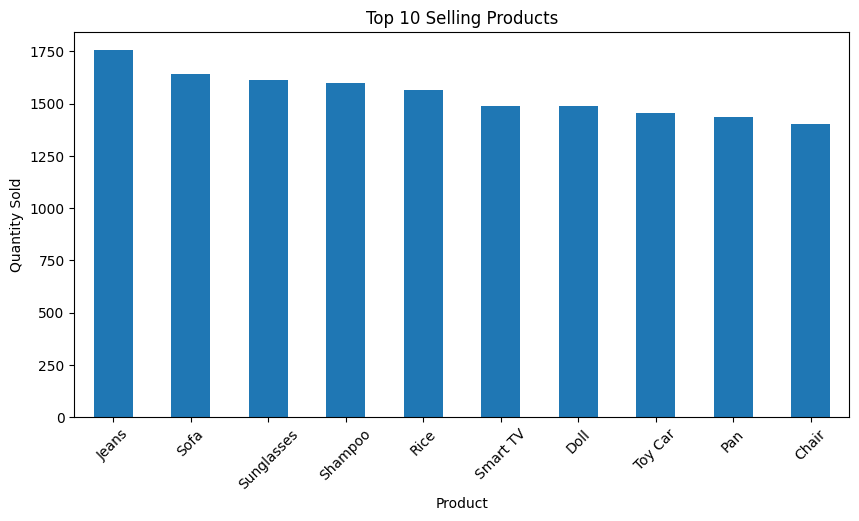

In [36]:
top_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

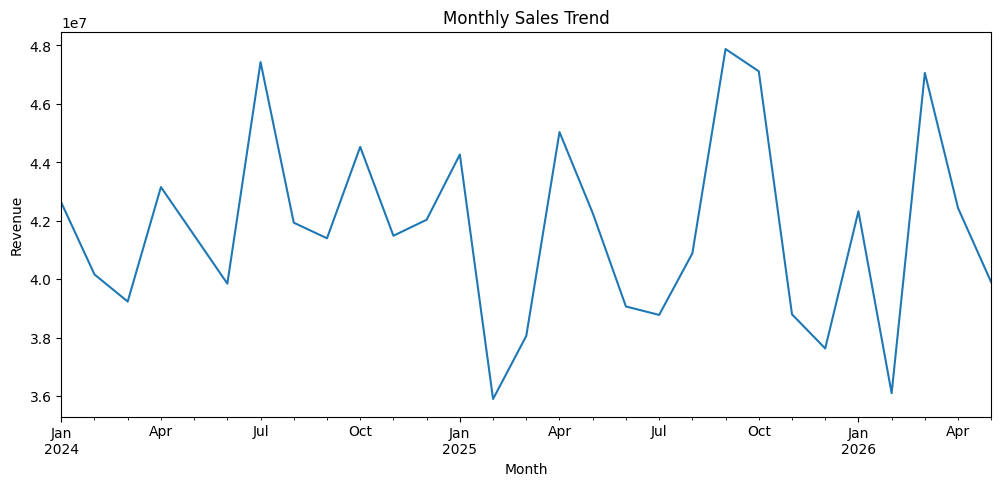

In [37]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()